# Credit Default Prediction using Cost-Sensitive Machine Learning

### Student Name: Gopal Reddy Marella  
### Course: MSc Data Science  
### University: University of Hertfordshire  

In [8]:
#Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Imbalance handling
from sklearn.utils.class_weight import compute_class_weight

# Advanced
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Load Excel file
df = pd.read_excel("default_of_credit_card_clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
#Quick look at dataset structure and basic stats of numerical columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [11]:
#  Rename target
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

# Drop ID
df.drop(columns=['ID'], inplace=True)

In [12]:
#  Fix invalid categories

df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace([0], 3)

In [14]:
# Define bill and payment columns
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Create average bill and payment features across months
df['avg_bill'] = df[bill_cols].mean(axis=1)
df['avg_payment'] = df[pay_cols].mean(axis=1)

# Calculate how much of the credit limit is being used
df['credit_utilization'] = df['avg_bill'] / df['LIMIT_BAL']

# Create payment ratio (handling division by zero safely)
df['payment_ratio'] = np.where(
    df['avg_bill'] == 0,
    0,
    df['avg_payment'] / df['avg_bill']
)

In [17]:
# Replace infinite values with NaN for proper handling
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [18]:
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month', 'avg_bill', 'avg_payment', 'credit_utilization', 'payment_ratio']


In [19]:
# Rename target column for easier reference
df.rename(columns={'default payment next month': 'default'}, inplace=True)

In [33]:
print(df.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default',
       'avg_bill', 'avg_payment', 'credit_utilization', 'payment_ratio'],
      dtype='object')


In [20]:
# Fill missing values using median of each column
df = df.fillna(df.median(numeric_only=True))

In [21]:
# Check if any missing values are still present
print(df.isnull().sum().sum())

0


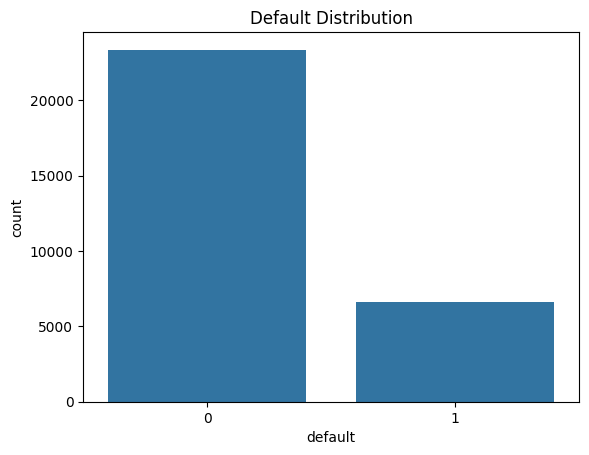

In [22]:
# Target imbalance
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

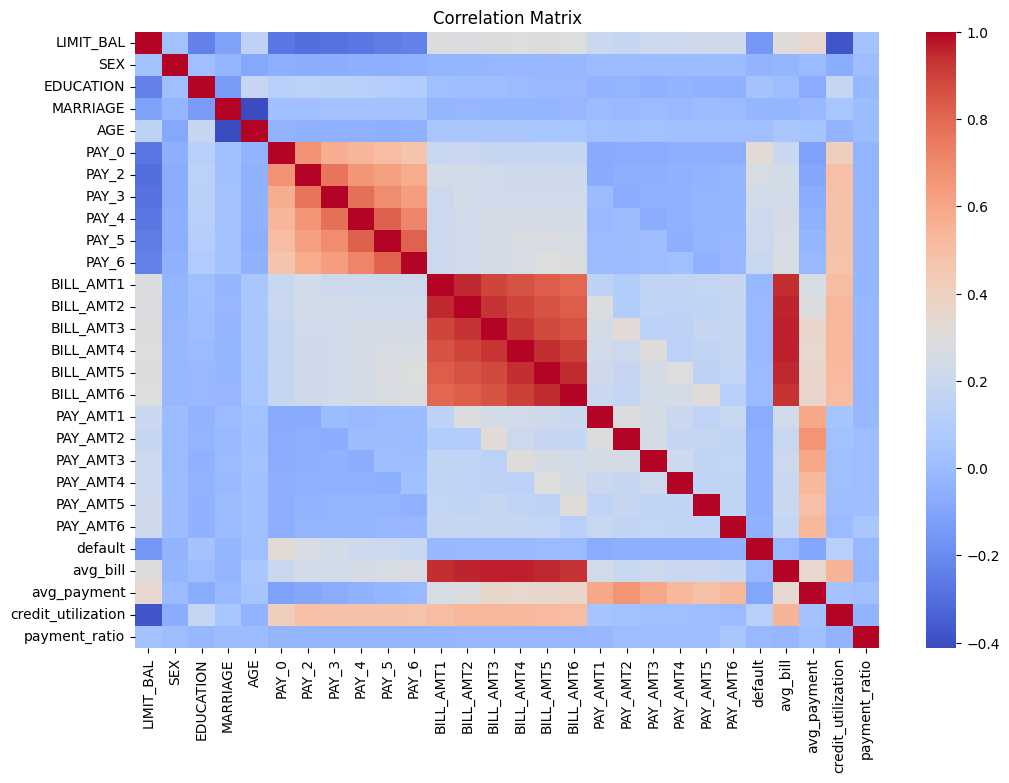

In [23]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

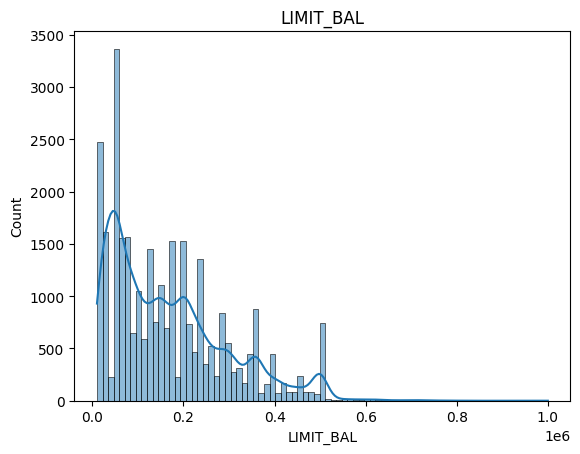

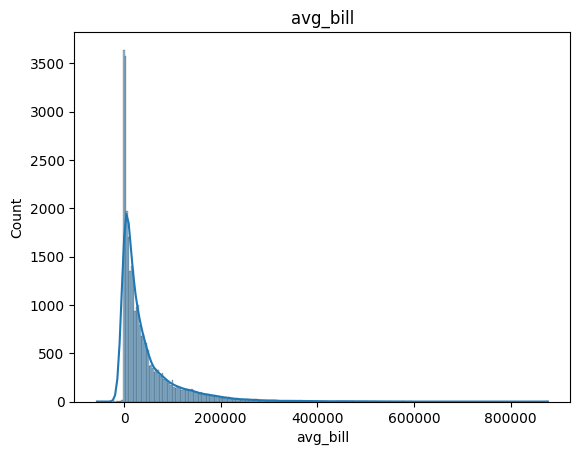

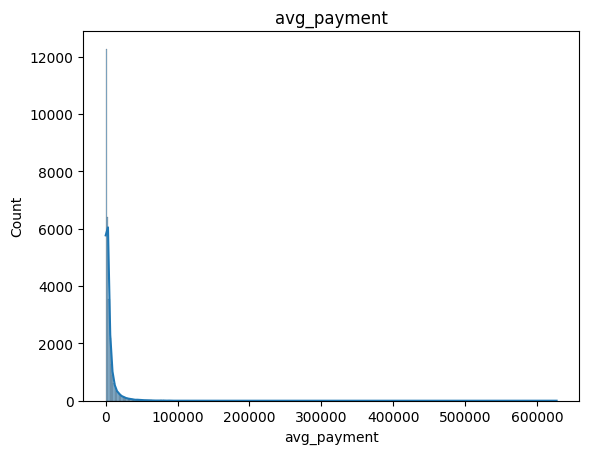

In [24]:
#  Distribution plots
for col in ['LIMIT_BAL','avg_bill','avg_payment']:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [25]:
# Split features and target variable
X = df.drop('default', axis=1)
y = df['default']
# Split data into training and testing sets (80-20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [26]:
# Apply feature scaling for models like Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Logistic Regression baseline

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

Accuracy: 0.8093333333333333
Recall: 0.24340617935192163


In [28]:
#  Random Forest baseline

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Recall:", recall_score(y_test, y_pred_rf))

Recall: 0.3579502637528259


In [29]:
# Compute class weights

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

print(class_weights)

{0: np.float64(0.6420202236370446), 1: np.float64(2.2603126765869277)}


In [30]:
# Logistic Regression (Cost-Sensitive)

lr_cs = LogisticRegression(class_weight=class_weights, max_iter=1000)
lr_cs.fit(X_train_scaled, y_train)

y_pred_lr_cs = lr_cs.predict(X_test_scaled)

print("Recall:", recall_score(y_test, y_pred_lr_cs))

Recall: 0.6164280331574982


In [31]:
# Random Forest (Cost-Sensitive)

rf_cs = RandomForestClassifier(class_weight='balanced')
rf_cs.fit(X_train, y_train)

y_pred_rf_cs = rf_cs.predict(X_test)

In [32]:
# XGBoost (Cost-sensitive via scale_pos_weight)

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_cs = XGBClassifier(scale_pos_weight=scale)
xgb_cs.fit(X_train, y_train)

y_pred_xgb_cs = xgb_cs.predict(X_test)

In [33]:
#  Financial cost function

COST_FN = 10000  # missing defaulter
COST_FP = 1000   # false alarm

def financial_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fn = cm[1][0]
    fp = cm[0][1]
    return fn * COST_FN + fp * COST_FP

In [34]:
# Compare financial cost

models = {
    "LR": y_pred_lr,
    "LR_CS": y_pred_lr_cs,
    "RF": y_pred_rf,
    "RF_CS": y_pred_rf_cs,
    "XGB_CS": y_pred_xgb_cs
}

for name, pred in models.items():
    print(name, "Cost:", financial_cost(y_test, pred))

LR Cost: 10180000
LR_CS Cost: 6472000
RF Cost: 8806000
RF_CS Cost: 9057000
XGB_CS Cost: 6633000


In [35]:
# Tune XGBoost model using GridSearch to improve recall

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale),
    param_grid,
    scoring='recall',
    cv=3
)

grid.fit(X_train, y_train)
# Get the best model after tuning
best_model = grid.best_estimator_

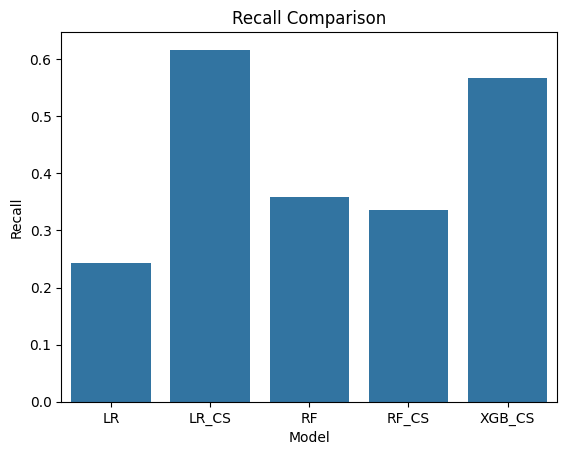

In [36]:
# Compare recall scores of different models
results = pd.DataFrame({
    "Model": list(models.keys()),
    "Recall": [recall_score(y_test, pred) for pred in models.values()]
})
# Plot recall comparison
sns.barplot(x='Model', y='Recall', data=results)
plt.title("Recall Comparison")
plt.show()

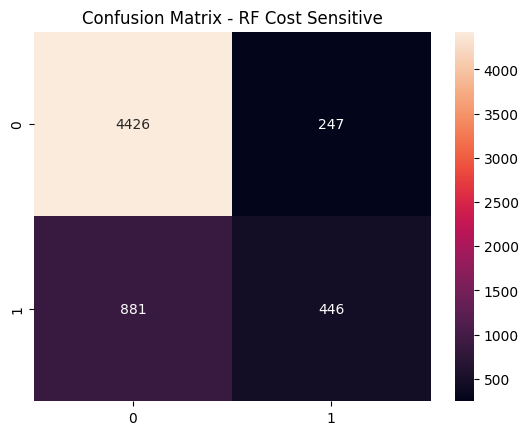

In [37]:
# Generate confusion matrix for cost-sensitive Random Forest

cm = confusion_matrix(y_test, y_pred_rf_cs)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - RF Cost Sensitive")
plt.show()

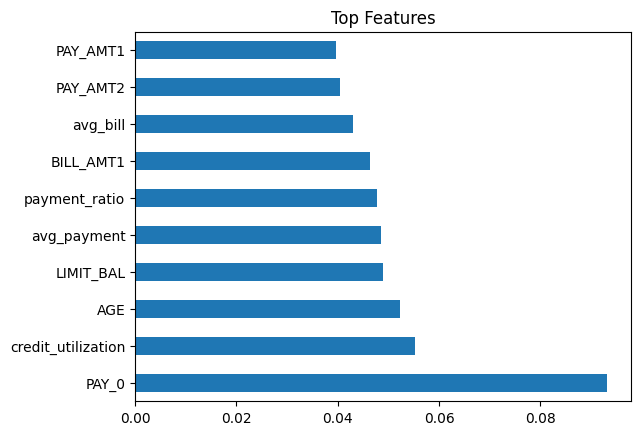

In [38]:
# Get feature importance from Random Forest model

feat_imp = pd.Series(rf_cs.feature_importances_, index=X.columns)
# Plot top 10 most important features
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

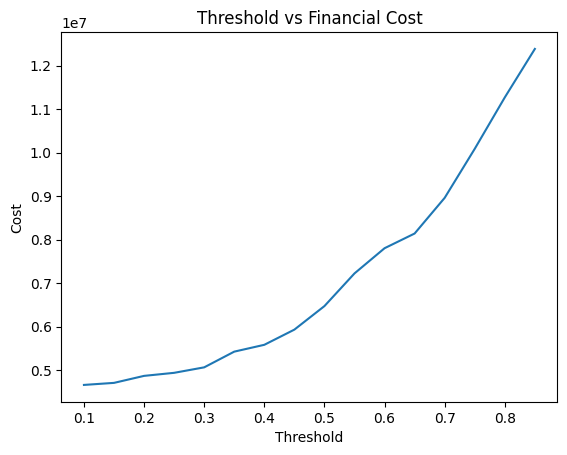

In [39]:
# Get prediction probabilities from cost-sensitive Logistic Regression

probs = lr_cs.predict_proba(X_test_scaled)[:,1]

# Test different thresholds and calculate financial cost
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    preds = (probs > t).astype(int)
    costs.append(financial_cost(y_test, preds))
    
# Plot threshold vs financial cost
plt.plot(thresholds, costs)
plt.title("Threshold vs Financial Cost")
plt.xlabel("Threshold")
plt.ylabel("Cost")
plt.show()

In [40]:
# Get the threshold that gives minimum financial cost
print("Best threshold:", thresholds[np.argmin(costs)])
print("Minimum cost:", min(costs))

Best threshold: 0.1
Minimum cost: 4660000


In [41]:
# Baseline probabilities
probs_base = lr.predict_proba(X_test_scaled)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)

costs_base = []
costs_cs = []

for t in thresholds:
    preds_base = (probs_base > t).astype(int)
    preds_cs = (probs > t).astype(int)

    costs_base.append(financial_cost(y_test, preds_base))
    costs_cs.append(financial_cost(y_test, preds_cs))

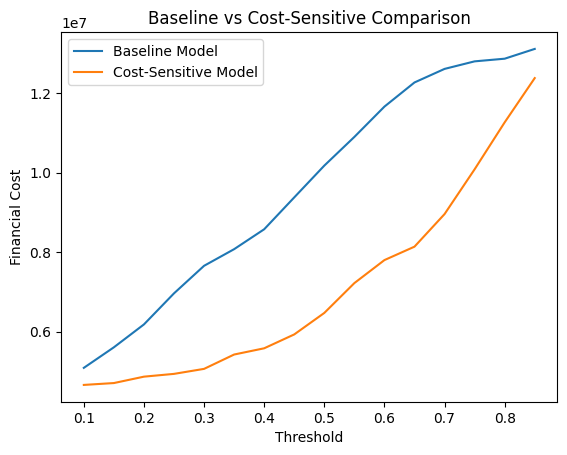

In [42]:
# Compare financial cost of baseline vs cost-sensitive model across thresholds
plt.plot(thresholds, costs_base, label="Baseline Model")
plt.plot(thresholds, costs_cs, label="Cost-Sensitive Model")

plt.xlabel("Threshold")
plt.ylabel("Financial Cost")
plt.title("Baseline vs Cost-Sensitive Comparison")
plt.legend()
plt.show()

In [43]:
# Compare financial cost at default threshold for both models
print("Baseline Cost (default threshold):", financial_cost(y_test, y_pred_lr))
print("Cost-Sensitive Cost:", financial_cost(y_test, y_pred_lr_cs))

Baseline Cost (default threshold): 10180000
Cost-Sensitive Cost: 6472000


In [44]:
# Compare recall of baseline and cost-sensitive models
print("Baseline Recall:", recall_score(y_test, y_pred_lr))
print("Cost-Sensitive Recall:", recall_score(y_test, y_pred_lr_cs))

Baseline Recall: 0.24340617935192163
Cost-Sensitive Recall: 0.6164280331574982


In [45]:
# Get the minimum cost achieved by each model across thresholds
best_base = min(costs_base)
best_cs = min(costs_cs)

print("Best Baseline Cost:", best_base)
print("Best Cost-Sensitive Cost:", best_cs)

Best Baseline Cost: 5090000
Best Cost-Sensitive Cost: 4660000


In [46]:
#import shap
import shap

In [47]:
# Using XGBoost model (best for SHAP explanations)

explainer = shap.TreeExplainer(xgb_cs)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

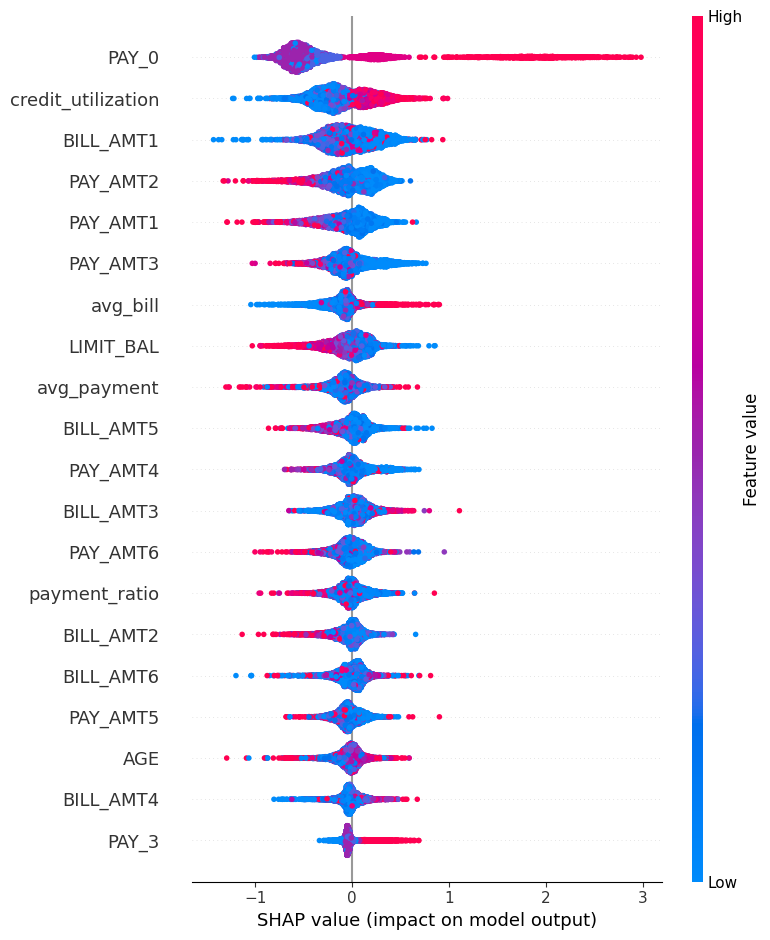

In [48]:
# This shows which features are most important overall

shap.summary_plot(shap_values, X_test)

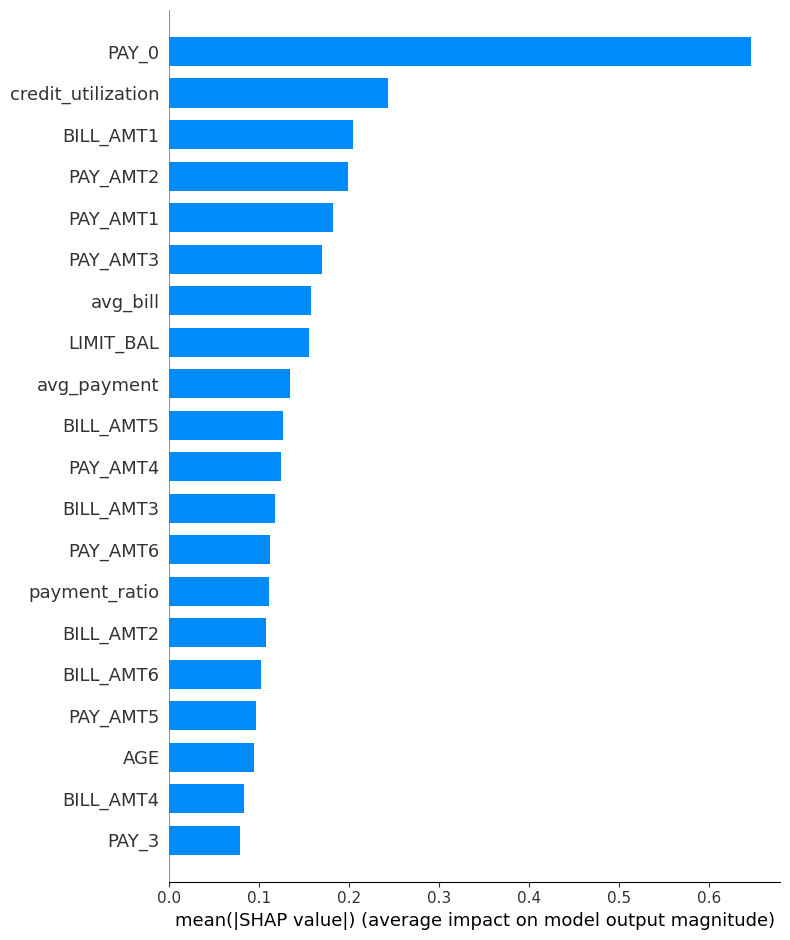

In [49]:
# Simple feature importance view (good for report)

shap.summary_plot(shap_values, X_test, plot_type="bar")

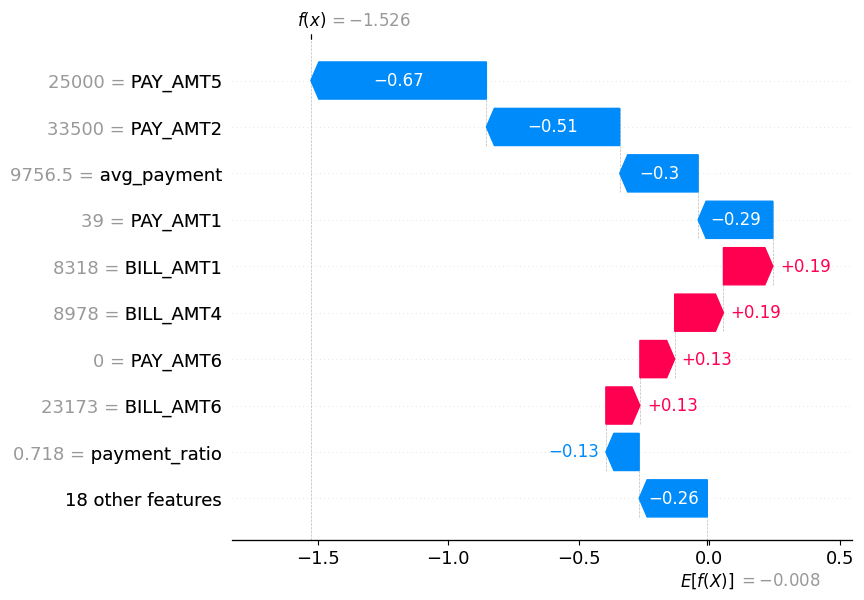

In [50]:
# Explain a single prediction

index = 10 

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_test.iloc[index]
    )
)

In [51]:
print("Most important feature:", X.columns[np.argmax(np.abs(shap_values).mean(0))])

Most important feature: PAY_0
